# Difference-in-Differences

## Goal

I use Difference-in-Differences to compare Baltimore with untreated ports before and after the bridge collapse.

Baltimore is the treated port.

April 2024 is the first full post-treatment month.

I exclude Norfolk because it received diverted Baltimore cargo after the collapse.

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/all_ports_imports.csv")

df["time"] = pd.to_datetime(df["time"])
df["VES_VAL_MO"] = pd.to_numeric(df["VES_VAL_MO"])

df = df[df["port"] != "Norfolk"]

df["treated"] = (df["port"] == "Baltimore").astype(int)
df["post"] = (df["time"] >= "2024-04-01").astype(int)

df.head()

,VES_VAL_MO,VES_WGT_MO,PORT_NAME,time,PORT,port,treated,post
0,3439162614,1213524503,"BALTIMORE, MD",2019-01-01,1303,Baltimore,1,0
1,3503063676,1120493870,"BALTIMORE, MD",2019-02-01,1303,Baltimore,1,0
2,3719890098,1063839057,"BALTIMORE, MD",2019-03-01,1303,Baltimore,1,0
3,4139140781,1075456430,"BALTIMORE, MD",2019-04-01,1303,Baltimore,1,0
4,3991269456,1197129890,"BALTIMORE, MD",2019-05-01,1303,Baltimore,1,0


In [ ]:
df["did"] = df["treated"] * df["post"]

df[["port", "time", "treated", "post", "did"]].head()

,port,time,treated,post,did
0,Baltimore,2019-01-01,1,0,0
1,Baltimore,2019-02-01,1,0,0
2,Baltimore,2019-03-01,1,0,0
3,Baltimore,2019-04-01,1,0,0
4,Baltimore,2019-05-01,1,0,0


## DiD Model

I estimate the average short-run effect from April through July 2024.

The model includes port fixed effects and month fixed effects.

The DiD coefficient measures how much Baltimore changed after the collapse relative to changes at untreated ports.

In [ ]:
did_df = df[df["time"] <= "2024-07-01"].copy()

did_df["import_billions"] = did_df["VES_VAL_MO"] / 1e9

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "import_billions ~ did + C(port) + C(time)",
    data=did_df
).fit()

model.params["did"]

np.float64(-1.5494640535089999)

## DiD Result

The DiD coefficient is -1.55.

From April through July 2024, Baltimore vessel imports were about $1.55B lower per month relative to the change observed at untreated ports.

This supports the Synthetic Control result, which also found a large short-run decline after the bridge collapse.

However, the DiD interpretation depends on the parallel trends assumption.

In [ ]:
model = smf.ols(
    "import_billions ~ did + C(port) + C(time)",
    data=did_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": did_df["port"]}
)

print("Coefficient:", model.params["did"])
print("SE:", model.bse["did"])
print("p-value:", model.pvalues["did"])

Coefficient: -1.5494640535089999
SE: 0.1085441812718083
p-value: 3.134590191044029e-46


## DiD Result

The DiD estimate is -1.55.

From April through July 2024, Baltimore vessel imports were about $1.55B lower per month relative to untreated ports.

The clustered standard error is about $0.11B.

Because there is only one treated port and a small number of clusters, I focus more on the effect size and pre-treatment trends than on the p-value.

## Parallel Trends Check

DiD assumes that Baltimore and the control ports would have followed similar trends without the bridge collapse.

I compare Baltimore's pre-treatment trend with the average control-port trend.

In [ ]:
control = (
    did_df[did_df["treated"] == 0]
    .groupby("time")["import_billions"]
    .mean()
)

baltimore = (
    did_df[did_df["treated"] == 1]
    .set_index("time")["import_billions"]
)

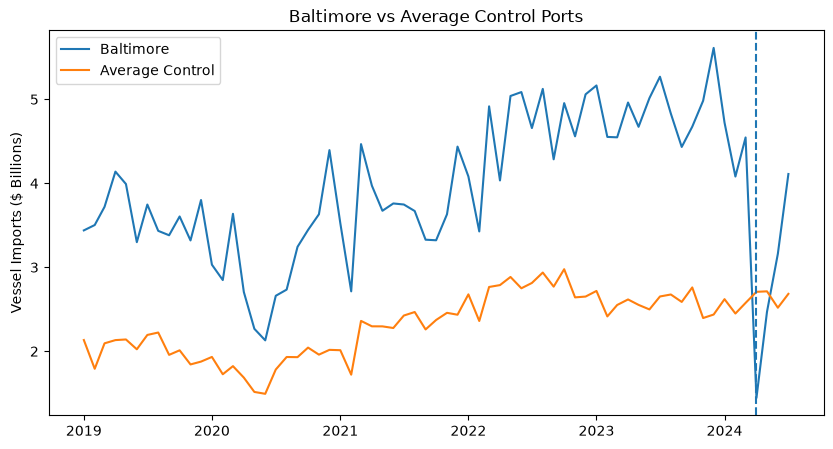

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(baltimore.index, baltimore, label="Baltimore")
plt.plot(control.index, control, label="Average Control")

plt.axvline(pd.Timestamp("2024-04-01"), linestyle="--")

plt.title("Baltimore vs Average Control Ports")
plt.ylabel("Vessel Imports ($ Billions)")
plt.legend()

plt.show()

## Parallel Trends Interpretation

Baltimore and the control ports generally move in the same direction before treatment.

However, Baltimore is more volatile and the gap between the groups changes over time.

Therefore, the parallel trends assumption is not especially strong.

I use DiD as supporting evidence, while Synthetic Control remains the main causal method because it provides a better pre-treatment counterfactual for Baltimore.

## DiD Conclusion

DiD estimates that Baltimore vessel imports fell by about $1.55B per month from April through July 2024 relative to untreated ports.

This supports the direction of the Synthetic Control result.

However, the pre-treatment trends are not perfectly parallel, so I treat DiD as a robustness check rather than the primary estimate.